**Name:** \_\_HAN Zhuo\_\_

**EID:** \_\_zhuohan3\_\_

# CS5489 - Assignment 1 - SMS Classification

## Final submission
In this file, put the code that generates your final CSV submission. It will be used to verify that your CSV submission is reproducible.

In [4]:
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
import matplotlib
from numpy import *
from sklearn import *
from scipy import stats
import csv
import pandas as pd
random.seed(100)

In [5]:
def read_text_data(fname):
    txtdata = []
    classes = []
    with open(fname, 'r', encoding='utf-8') as csvfile:
        reader = csv.reader(csvfile, delimiter=',', quotechar='"')
        for row in reader:
            # get the text
            txtdata.append(row[0])
            # get the class (convert to integer)
            if len(row)>1:
                classes.append(int(row[1]))

    return (txtdata, classes)

def write_csv(fname, Y):
    # fname = file name
    # Y is a list/array with class entries

    # header
    tmp = [['Id', 'Prediction']]

    # add ID numbers for each Y
    for (i,y) in enumerate(Y):
        tmp2 = [(i+1), y]
        tmp.append(tmp2)

    # write CSV file
    with open(fname, 'w') as f:
        writer = csv.writer(f)
        writer.writerows(tmp)

In [6]:
# load the data
(traintxt, trainY) = read_text_data("smishing_train.txt")
(testtxt, _)       = read_text_data("smishing_val_test.txt")
testY              = pd.read_csv("smishing_val_test.csv")
print(len(traintxt))
print(len(testtxt))
testY.head()

2985
2986


,Id,Prediction,Usage
0,1,0,val
1,2,0,test
2,3,0,val
3,4,0,test
4,5,0,val


In [7]:
### INSERT YOUR CODE HERE
# INSERT YOUR CODE HERE
import os
import sys
import math
import random
import json
import csv
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [8]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [9]:
DATA_DIR = Path(".")
TRAIN_TXT = DATA_DIR / "smishing_train.txt"
VAL_TEST_TXT = DATA_DIR / "smishing_val_test.txt"
VAL_TEST_CSV = DATA_DIR / "smishing_val_test.csv"

for p in [TRAIN_TXT, VAL_TEST_TXT, VAL_TEST_CSV]:
    assert p.exists(), f"File not found: {p}"

In [10]:
(traintxt, trainY) = read_text_data("smishing_train.txt")
(testtxt, _)       = read_text_data("smishing_val_test.txt")
testY              = pd.read_csv("smishing_val_test.csv")
print(len(traintxt), type(traintxt))
print(len(trainY), type(trainY))
print(len(testtxt), type(testtxt))
testY.tail()

2985 <class 'list'>
2985 <class 'list'>
2986 <class 'list'>


,Id,Prediction,Usage
2981,2982,0,test
2982,2983,0,val
2983,2984,0,test
2984,2985,0,val
2985,2986,0,test


In [11]:
train_df = pd.DataFrame({'text': traintxt, 'label': trainY})
print(f"Train shape: {train_df.shape}")
# print(train_df.head(3))

valtest_txt_df = pd.DataFrame({"ID": np.arange(1, len(testtxt) + 1, dtype=int), 'text': testtxt})
print(f"Val/Test shape: {valtest_txt_df.shape}")
valtest_txt_df.head(3)

Train shape: (2985, 2)
Val/Test shape: (2986, 2)


,ID,text
0,1,Then u drive lor.
1,2,Hey i booked the kb on sat already... what oth...
2,3,K:)k:)good:)study well.


In [12]:
for df in (testY, valtest_txt_df):
    df.columns = df.columns.str.strip()
valtest_txt_df.rename(columns={'\ufeffId':'Id','ID':'Id','id':'Id'}, inplace=True)

if 'Id' in testY.index.names: testY = testY.reset_index()
if 'Id' in valtest_txt_df.index.names: valtest_txt_df = valtest_txt_df.reset_index()

testY['Id'] = pd.to_numeric(testY['Id'], errors='coerce').astype('Int64')
valtest_txt_df['Id'] = pd.to_numeric(valtest_txt_df['Id'], errors='coerce').astype('Int64')

valtest_merged = pd.merge(
    testY, valtest_txt_df,
    on='Id', how='left', validate='one_to_one'
)


In [13]:

valtest_merged = pd.merge(
    testY.assign(Id=testY['Id'].astype(int)),
    valtest_txt_df, 
    on="Id",
    how="left",
    validate="one_to_one"
    )
print(f"Merged val/test shape: {valtest_merged.shape}")
valtest_merged.head(3)

Merged val/test shape: (2986, 4)


,Id,Prediction,Usage,text
0,1,0,val,Then u drive lor.
1,2,0,test,Hey i booked the kb on sat already... what oth...
2,3,0,val,K:)k:)good:)study well.


In [14]:
if valtest_merged['text'].isnull().any():
    missing = valtest_merged[valtest_merged['text'].isnull()]
    print(f"Missing text for {len(missing)} rows:")
    print(missing)
else:
    print("No missing text entries.")

No missing text entries.


In [15]:
labels_names = {0: "normal", 1: "spam", 2: "smishing"}

counts = train_df['label'].value_counts().reindex([0, 1, 2]).fillna(0).astype(int)
total = int(counts.sum())
ratios = (counts/max(total)).round(4)

print(f"Label counts:")
for k in [0, 1, 2]:
    print(f"  {labels_names[k]:8s}: {counts[k]:4d} ({ratios[k]:.2%})")
print(f"Total: {total}")

expected = {0: 2454, 1: 234, 2: 297}
mismatch = {k: (counts[k], expected[k]) for k in [0,1,2] if counts[k] != expected[k]}
if mismatch:
    print("NOTE: counts differ from assignment sheet (actual, expected) =", mismatch)
else:
    print("Counts match the assignment sheet.")


Label counts:
  normal  : 2454 (82.21%)
  spam    :  234 (7.84%)
  smishing:  297 (9.95%)
Total: 2985
Counts match the assignment sheet.


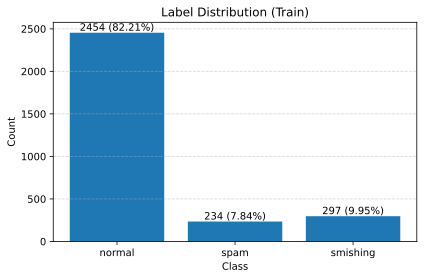

In [16]:
names = [labels_names[i] for i in [0, 1, 2]]
vals  = counts.values

plt.figure(figsize=(6, 4))
bars = plt.bar(names, vals)
plt.title("Label Distribution (Train)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for b, c in zip(bars, vals):
    pct = (c / total * 100.0) if total > 0 else 0.0
    plt.text(b.get_x() + b.get_width()/2, b.get_height(),
             f"{c} ({pct:.2f}%)",
             ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


In [17]:
import re, unicodedata, string
from urllib.parse import urlparse

URL_RE = re.compile(r"(https?://\S+|www\.\S+)", re.I)
NUM_RE = re.compile(r"\b\d+(?:[.,]\d+)?\b")            
EMAIL_RE = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", re.I)

def extract_domain(u: str) -> str:
    try:
        if not u.lower().startswith(("http://", "https://")):
            u = "http://" + u
        host = urlparse(u).hostname or ""
    except Exception:
        host = ""
    return host.lower()

def normalize_trad(s: str) -> str:
    if not isinstance(s, str):
        s = str(s)
    s = unicodedata.normalize("NFKC", s)
    s = URL_RE.sub("__URL__", s)
    s = EMAIL_RE.sub("__EMAIL__", s)
    s = NUM_RE.sub("__NUM__", s)
    s = s.lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

train_df["text_norm"] = train_df["text"].map(normalize_trad)
valtest_txt_df["text_norm"]   = valtest_txt_df["text"].map(normalize_trad)
valtest_merged["text_norm"]  = valtest_merged["text"].map(normalize_trad)

train_df[["text", "text_norm"]].head(3)
valtest_txt_df[["text", "text_norm"]].head(3)
valtest_merged[["text", "text_norm"]].head(3)

# train_df.head()
# valtest_merged.head()

val_df = (valtest_merged.loc[valtest_merged["Usage"].str.lower()=="val"].sort_values("Id").reset_index(drop=True))
test_df = (valtest_merged.loc[valtest_merged["Usage"].str.lower()=="test"].sort_values("Id").reset_index(drop=True))

# val_df  = valtest_txt_df.loc[valtest_merged["Usage"].str.lower()=="val"].sort_values("Id").reset_index(drop=True)
# test_df = valtest_txt_df.loc[valtest_merged["Usage"].str.lower()=="test"].sort_values("Id").reset_index(drop=True)

print(train_df.shape, val_df.shape, test_df.shape)
# train_df.head(2), val_df.head(2), test_df.head(2)
test_df.head()



(2985, 3) (1493, 5) (1493, 5)


,Id,Prediction,Usage,text,text_norm
0,2,0,test,Hey i booked the kb on sat already... what oth...,hey i booked the kb on sat already... what oth...
1,4,0,test,Hmm .. Bits and pieces lol ... *sighs* ...,hmm .. bits and pieces lol ... *sighs* ...
2,6,0,test,10 min later k...,__num__ min later k...
3,8,2,test,FREE2DAY sexy St George's Day pic of Jordan!Tx...,free2day sexy st george's day pic of jordan!tx...
4,10,2,test,Your B4U voucher w/c 27/03 is MARSMS. Log onto...,your b4u voucher w/c __num__/__num__ is marsms...


In [18]:
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

def evaluate_model(model, name, X_train, y_train, X_val=None, y_val=None):
    model.fit(X_train, y_train)

    # Train
    y_tr = model.predict(X_train)
    acc_tr = accuracy_score(y_train, y_tr)
    f1_tr  = f1_score(y_train, y_tr, average='macro')

    out = {
        "model": name,
        "train_acc": acc_tr,
        "train_macro_f1": f1_tr,
        "val_acc": None,
        "val_macro_f1": None,
        "val_cm": None,
        "val_pred": None,
        "estimator": model
    }

    print(f"\n===== {name} =====")
    print(f"Train Acc: {acc_tr:.4f} | Macro-F1: {f1_tr:.4f}")

    if X_val is not None:
        y_va = model.predict(X_val)
        out["val_pred"] = y_va
        if y_val is not None:
            acc_va = accuracy_score(y_val, y_va)
            f1_va  = f1_score(y_val, y_va, average='macro')
            cm_va  = confusion_matrix(y_val, y_va)
            out.update({"val_acc": acc_va, "val_macro_f1": f1_va, "val_cm": cm_va})
            print(f"Valid Acc: {acc_va:.4f} | Macro-F1: {f1_va:.4f}")
            print("Valid Confusion Matrix (rows=true, cols=pred):\n", cm_va)
        else:
            print("Valid: no labels provided (predictions only).")
    return out

In [19]:
train_texts = train_df["text_norm"].astype(str).values
train_labels = train_df["label"].astype(np.int64).values
val_texts = val_df["text_norm"].astype(str).values
val_labels = val_df["Prediction"].astype(np.int64).values

In [20]:
## Generative
### GNB Count n-gram
gnb_count = Pipeline([
    ("count", CountVectorizer(max_features=50000, ngram_range=(1,2))),
    ("todense", FunctionTransformer(lambda X: X.toarray(), accept_sparse=True)),
    ("clf", GaussianNB(var_smoothing=1e-8))
])

### GNB TF-IDF SVD
gnb_tfidf_svd = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("svd",   TruncatedSVD(n_components=200, random_state=SEED)),
    ("scale", StandardScaler(with_mean=True)),
    ("clf",   GaussianNB(var_smoothing=1e-8))
])

### LDA TF-IDF SVD
lda_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("svd",   TruncatedSVD(n_components=200, random_state=SEED)),
    ("scale", StandardScaler(with_mean=True)),
    ("clf",   LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
])

### QDA TF-IDF SVD
qda_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("svd",   TruncatedSVD(n_components=200, random_state=SEED)),
    ("scale", StandardScaler(with_mean=True)),
    ("clf",   QuadraticDiscriminantAnalysis(reg_param=0.1))
])

## Discriminative
### LR
lr_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("scale", StandardScaler(with_mean=False)),
    ("clf",   LogisticRegression(C=1.0, penalty="l2", solver="liblinear",
                                 class_weight="balanced", max_iter=200, random_state=SEED))
])

### Linear SVM
linear_svm_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("scale", StandardScaler(with_mean=False)),
    ("clf",   LinearSVC(C=1.0, class_weight="balanced", random_state=SEED))
])

### Kernel SVM
rbf_svm_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1,2))),
    ("scale", StandardScaler(with_mean=False)),
    ("clf",   SVC(kernel="rbf", C=10.0, gamma=1e-4, class_weight="balanced", random_state=SEED))
])

## Others
### Decision Tree
dt_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1,2))),
    ("clf",   DecisionTreeClassifier(max_depth=16, min_samples_leaf=5, random_state=SEED))
])

### Random Forest
rf_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1,2))),
    ("clf",   RandomForestClassifier(n_estimators=400, max_depth=None, n_jobs=-1, random_state=SEED))
])

### MLP
mlp_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("svd",   TruncatedSVD(n_components=200, random_state=SEED)),
    ("scale", StandardScaler(with_mean=True)),
    ("clf",   MLPClassifier(hidden_layer_sizes=(256, 128), activation="relu",
                            alpha=1e-4, learning_rate_init=1e-3,
                            batch_size=64, max_iter=50, early_stopping=True,
                            random_state=SEED))
])

In [21]:
from sklearn.model_selection import ParameterGrid
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

def fit_and_eval(pipe, Xtr, ytr, Xval, yval):
    pipe.fit(Xtr, ytr)
    val_pred = pipe.predict(Xval)
    return {
        "val_macro_f1": f1_score(yval, val_pred, average="macro"),
        "val_acc": accuracy_score(yval, val_pred),
        "val_pred": val_pred
    }
    
search_spaces = [
    # Generative
    ("GNB (Count)", gnb_count, {     
        "clf__var_smoothing": np.logspace(-12, -7, 6),
    }),
    ("GNB (TF-IDF+SVD)", gnb_tfidf_svd, {  
        "clf__var_smoothing": np.logspace(-12, -7, 6),
        "svd__n_components": [100, 200, 300],  
    }),

    # LDA/QDA
    ("LDA", lda_pipe, {
        "svd__n_components": [100, 200, 300],
        "clf__shrinkage": ["auto", 0.0, 0.05, 0.1, 0.2, 0.5],
        "clf__solver": ["lsqr"],
    }),
    ("QDA", qda_pipe, {
        "svd__n_components": [100, 200, 300],
        "clf__reg_param": [0.0, 1e-4, 1e-3, 1e-2, 0.05, 0.1, 0.2, 0.5],
    }),

    # Discriminative
    ("LR", lr_pipe, {                      
        "clf__C": np.logspace(-3, 3, 7),
        "clf__penalty": ["l2"],
        "clf__solver": ["liblinear"],      
        "clf__class_weight": ["balanced"],
        "clf__max_iter": [200, 400],
    }),

    ("Linear SVM", linear_svm_pipe, {
        "clf__C": np.logspace(-3, 3, 7),
        "clf__loss": ["hinge", "squared_hinge"],
        "clf__max_iter": [2000],
    }),

    ("Kernel SVM", rbf_svm_pipe, { 
        "tfidf__max_features": [30000, 50000],    
        "clf__C": np.logspace(-1, 3, 5),          
        "clf__gamma": np.logspace(-4, 0, 5),     
    }),

    # Trees
    ("Decision Tree", dt_pipe, {
        "tfidf__max_features": [30000, 50000],
        "clf__max_depth": [5, 10, 20, None],
        "clf__min_samples_leaf": [1, 2, 5, 10],
    }),

    ("Random Forest", rf_pipe, {
        "tfidf__max_features": [30000, 50000],
        "clf__n_estimators": [200, 400, 800],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_leaf": [1, 2, 5],
        "clf__n_jobs": [-1],
    }),

    # MLP
    # ("MLP", mlp_pipe, {
    #     "svd__n_components": [100, 200, 300],
    #     "clf__hidden_layer_sizes": [(256, 128), (256,), (384, 128)],
    #     "clf__alpha": np.logspace(-6, -2, 5),         # L2 norm
    #     "clf__learning_rate_init": np.logspace(-4, -2, 3),
    #     "clf__early_stopping": [True],
    #     "clf__max_iter": [80],                         
    # }),
    ("MLP", mlp_pipe, {
    "tfidf__sublinear_tf": [True],
    "tfidf__min_df": [2],
    "svd__n_components": [200, 300],
    "clf__hidden_layer_sizes": [(512,), (384, 128), (256, 128)],
    "clf__learning_rate": ["adaptive"],
    "clf__learning_rate_init": [5e-4, 1e-3, 2e-3],
    "clf__alpha": [3e-5, 1e-4, 3e-4],
    "clf__early_stopping": [True],
    "clf__n_iter_no_change": [8, 12],
    "clf__max_iter": [120],
    "clf__batch_size": [64],
}),
]

In [22]:
best_results = []
misclassified_cases = {}
print("===== Hyperparam search on validation (by Macro-F1) =====")
for name, base_pipe, grid in search_spaces:
    best = {"val_macro_f1": -1, "val_acc": -1, "params": None, "val_pred": None, "model": None}
    for params in ParameterGrid(grid):
        pipe = base_pipe.set_params(**params)
        out = fit_and_eval(pipe, train_texts, train_labels, val_texts, val_labels)
        if out["val_macro_f1"] > best["val_macro_f1"]:
            best.update({
                "val_macro_f1": out["val_macro_f1"],
                "val_acc": out["val_acc"],
                "params": params,
                "val_pred": out["val_pred"],
                "model": pipe
            })
    print(f"\n[{name}] best on VAL | MaF={best['val_macro_f1']:.4f}, Acc={best['val_acc']:.4f}")
    print("  best params:", best["params"])
    best_results.append((name, best))

print("\n===== Evaluate the chosen settings on TEST =====")
for name, best in best_results:
    best_model = best["model"]
    best_model.fit(train_texts, train_labels)
    test_pred = best_model.predict(test_df["text_norm"])
    current_misclassified_cases = []
    if "Prediction" in test_df.columns:
        X_test = test_df["text_norm"].astype(str).values
        y_test = test_df["Prediction"].astype(np.int64).values
        test_acc = accuracy_score(test_df["Prediction"], test_pred)
        test_maf = f1_score(test_df["Prediction"], test_pred, average="macro")
        print(f"[{name}] TEST | MaF={test_maf:.4f}, Acc={test_acc:.4f}")
        
        mask = (test_pred != y_test)
        idxs = np.where(mask)[0]
        for i in idxs:
            row = test_df.iloc[i]
            current_misclassified_cases.append({
                "Id": int(row["Id"]),
                "text": row["text"],
                "true": int(row["Prediction"]),
                "pred": int(test_pred[i])
            })
        
    else:
        print(f"[{name}] TEST predictions head:", test_pred[:10])
    misclassified_cases.update({name: current_misclassified_cases})


===== Hyperparam search on validation (by Macro-F1) =====

[GNB (Count)] best on VAL | MaF=0.7997, Acc=0.9203
  best params: {'clf__var_smoothing': np.float64(1e-12)}

[GNB (TF-IDF+SVD)] best on VAL | MaF=0.6963, Acc=0.8513
  best params: {'clf__var_smoothing': np.float64(1e-12), 'svd__n_components': 100}

[LDA] best on VAL | MaF=0.8795, Acc=0.9571
  best params: {'clf__shrinkage': 0.05, 'clf__solver': 'lsqr', 'svd__n_components': 300}

[QDA] best on VAL | MaF=0.8395, Acc=0.9344
  best params: {'clf__reg_param': 0.05, 'svd__n_components': 200}

[LR] best on VAL | MaF=0.8367, Acc=0.9431
  best params: {'clf__C': np.float64(0.01), 'clf__class_weight': 'balanced', 'clf__max_iter': 200, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}

[Linear SVM] best on VAL | MaF=0.8223, Acc=0.9390
  best params: {'clf__C': np.float64(0.001), 'clf__loss': 'hinge', 'clf__max_iter': 2000}

[Kernel SVM] best on VAL | MaF=0.6233, Acc=0.8788
  best params: {'clf__C': np.float64(1.0), 'clf__gamma': np.float6

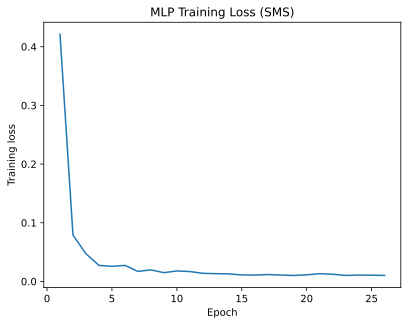

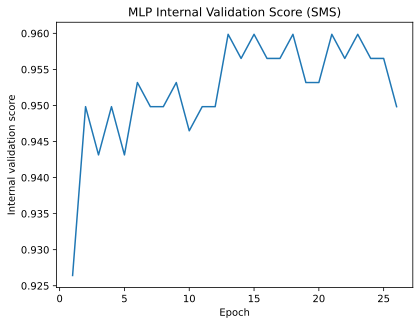

[MLP] External VAL | Macro-F1=0.9060, Acc=0.9685


In [23]:
# Learning Curves for the MLP model
mlp_entry = next(((n, b) for (n, b) in best_results if n.lower().startswith("mlp")), None)

if mlp_entry is None:
    print("No MLP in best_results; skip learning curves.")
else:
    name, best = mlp_entry
    
    mlp_pipe = clone(best["model"])
    mlp_pipe.fit(train_texts, train_labels)

    
    try:
        mlp = mlp_pipe.named_steps["clf"]
    except KeyError:
        mlp = next((s for s in mlp_pipe.named_steps.values() if isinstance(s, MLPClassifier)), None)

    if mlp is None:
        print("Cannot locate MLPClassifier inside the pipeline.")
    else:
        
        loss_curve = getattr(mlp, "loss_curve_", None)
        val_scores = getattr(mlp, "validation_scores_", None)

        if loss_curve is not None and len(loss_curve) > 0:
            plt.figure()
            plt.plot(range(1, len(loss_curve) + 1), loss_curve)
            plt.xlabel("Epoch"); plt.ylabel("Training loss")
            plt.title("MLP Training Loss (SMS)")
            plt.show()

        plt.figure()
        plt.plot(range(1, len(val_scores) + 1), val_scores)
        plt.xlabel("Epoch"); plt.ylabel("Internal validation score")
        plt.title("MLP Internal Validation Score (SMS)")
        plt.show()

            
        yv = mlp_pipe.predict(val_texts)
        print(f"[MLP] External VAL | Macro-F1={f1_score(val_labels, yv, average='macro'):.4f}, "
                  f"Acc={accuracy_score(val_labels, yv):.4f}")


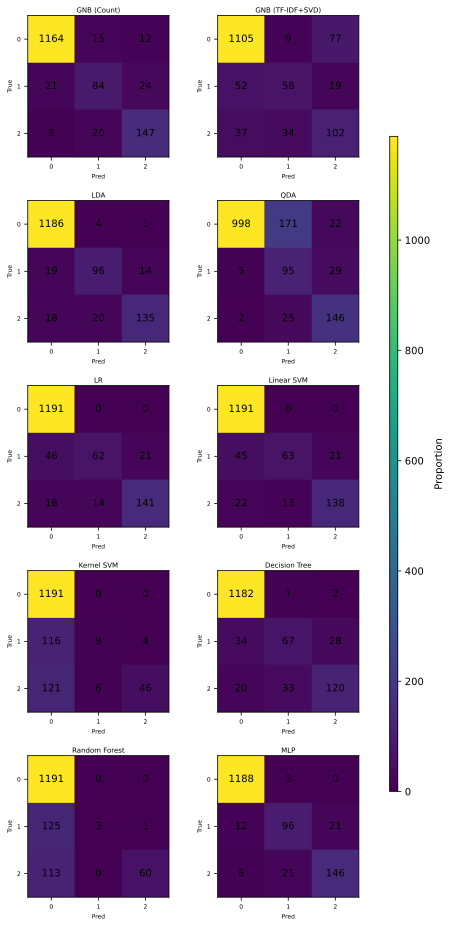

In [24]:
X_eval = test_df["text_norm"]
y_eval = test_df["Prediction"]
split_name = "TEST"

COLS = 2            # 每行显示几个模型，可自行调整
cms, names = [], []

for name, info in best_results:
    pipe = clone(info["model"])
    pipe.fit(train_texts, train_labels)

    y_pred = pipe.predict(X_eval)
    labels_sorted = np.sort(np.unique(np.concatenate([y_eval, y_pred])))
    cm = confusion_matrix(y_eval, y_pred, labels=labels_sorted)
    cms.append(cm)
    names.append(name)

    # print(f"\n=== {name} on {split_name} ===")
    # print(classification_report(y_eval, y_pred, digits=4))

N = len(cms)
rows = math.ceil(N / COLS)

ffig, axes = plt.subplots(rows, COLS, figsize=(2.8 * COLS, 2.6 * rows))
axes = np.array(axes).reshape(rows, COLS)

# import matplotlib.colors as mcolors
# norm = mcolors.LogNorm(vmin=cm.min()+1, vmax=cm.max())

# cmap = cm.get_cmap("magma").copy()
# cmap.set_bad('black')  # 让 NaN 或 mask 掩盖的值显示为黑色

# 将 0 值屏蔽，使其显示为黑色
# cm_masked = np.ma.masked_less_equal(cm, 0)

for i, (ax, cm, name) in enumerate(zip(axes.ravel(), cms, names)):
    im = ax.imshow(cm, interpolation="nearest", cmap="viridis", vmin=0, vmax=cm.max())
    ax.set_title(f"{name}", fontsize=7, pad=3)
    ax.set_xlabel("Pred", fontsize=6)
    ax.set_ylabel("True", fontsize=6)
    labels_sorted = range(cm.shape[0])
    ax.set_xticks(labels_sorted)
    ax.set_yticks(labels_sorted)
    ax.set_xticklabels(labels_sorted, fontsize=6)
    ax.set_yticklabels(labels_sorted, fontsize=6)

    # 数值显示也缩小字号
    for (r, c), val in np.ndenumerate(cm):
        ax.text(c, r, str(int(val)), ha="center", va="center", fontsize=10)
    
# 隐藏空白子图
for j in range(i + 1, rows * COLS):
    axes.ravel()[j].axis("off")
    
plt.subplots_adjust(wspace=0.35, hspace=0.45, right=0.88)  # 给右边空出位置放colorbar

# 在最右侧添加纵向 colorbar
cbar_ax = ffig.add_axes([1.0, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
ffig.colorbar(im, cax=cbar_ax, orientation="vertical", label="Proportion")

plt.tight_layout()
plt.show()


In [25]:
# Take a peak at misclassified examples 
# eval_df = pd.DataFrame({
#     "text": X_test,
#     "y_true": y_test,
#     "y_pred": test_pred
# })
# eval_df["correct"] = (eval_df["y_true"] == eval_df["y_pred"])
# N = 10
# print("10 misclassfied examples by MLP:")
# display(eval_df.loc[~eval_df["correct"]][["y_true", "y_pred", "text"]])
for model_name, cases in misclassified_cases.items():
    if not cases:
        print(f"No misclassified cases for {model_name}.")
        continue
    print(f"\n10 misclassified examples by {model_name}:")
    df = pd.DataFrame(cases)
    display(df.head(10))


10 misclassified examples by GNB (Count):


,Id,text,true,pred
0,8,FREE2DAY sexy St George's Day pic of Jordan!Tx...,2,1
1,12,thesmszone.com lets you send free anonymous an...,1,0
2,26,U can WIN £100 of Music Gift Vouchers every we...,1,2
3,50,Hey I am really * want to chat or see me text...,2,1
4,130,(Help-Center Canada) You received a Transfer f...,2,0
5,166,Can U get 2 phone NOW? I wanna chat 2 set up m...,1,0
6,238,You are being ripped off! Get your mobile cont...,1,2
7,268,We have sent JD for Customer Service cum Accou...,0,1
8,270,That is wondarfull song,0,1
9,272,\tThe current leading bid is 151. To pause thi...,2,1



10 misclassified examples by GNB (TF-IDF+SVD):


,Id,text,true,pred
0,8,FREE2DAY sexy St George's Day pic of Jordan!Tx...,2,0
1,10,Your B4U voucher w/c 27/03 is MARSMS. Log onto...,2,1
2,12,thesmszone.com lets you send free anonymous an...,1,0
3,30,What class of &lt;#&gt; reunion?,0,2
4,50,Hey I am really * want to chat or see me text...,2,0
5,64,This weeks SavaMob member offers are now acces...,2,0
6,70,Haiyoh... Maybe your hamster was jealous of mi...,0,2
7,90,"Claim a 200 shopping spree, just call 08717895...",2,0
8,110,Oh all have to come ah?,0,2
9,130,(Help-Center Canada) You received a Transfer f...,2,0



10 misclassified examples by LDA:


...

,Id,text,true,pred
0,10,Your B4U voucher w/c 27/03 is MARSMS. Log onto...,2,1
1,12,thesmszone.com lets you send free anonymous an...,1,0
2,26,U can WIN £100 of Music Gift Vouchers every we...,1,2
3,46,Yeah so basically any time next week you can g...,0,1
4,50,Hey I am really * want to chat or see me text...,2,1
5,66,Ok. Can be later showing around 8-8:30 if you ...,0,1
6,96,Your 2004 account for 07XXXXXXXXX shows 786 un...,2,1
7,102,URGENT! Your Mobile number has been awarded a ...,2,1
8,166,Can U get 2 phone NOW? I wanna chat 2 set up m...,1,2
9,238,You are being ripped off! Get your mobile cont...,1,2



10 misclassified examples by Random Forest:


,Id,text,true,pred
0,8,FREE2DAY sexy St George's Day pic of Jordan!Tx...,2,0
1,10,Your B4U voucher w/c 27/03 is MARSMS. Log onto...,2,0
2,12,thesmszone.com lets you send free anonymous an...,1,0
3,26,U can WIN £100 of Music Gift Vouchers every we...,1,0
4,36,"ATM BLOCK:Dear customer, Due to our system upg...",2,0
5,50,Hey I am really * want to chat or see me text...,2,0
6,64,This weeks SavaMob member offers are now acces...,2,0
7,74,Hello from Orange. For 1 month's free access t...,1,0
8,78,You have 1 new message. Please call 08718738034.,2,0
9,90,"Claim a 200 shopping spree, just call 08717895...",2,0



10 misclassified examples by MLP:


,Id,text,true,pred
0,8,FREE2DAY sexy St George's Day pic of Jordan!Tx...,2,1
1,50,Hey I am really * want to chat or see me text...,2,1
2,166,Can U get 2 phone NOW? I wanna chat 2 set up m...,1,0
3,238,You are being ripped off! Get your mobile cont...,1,2
4,272,\tThe current leading bid is 151. To pause thi...,2,1
5,426,"Dear Voucher Holder, 2 claim this weeks offer,...",1,2
6,444,\tI'd like to tell you my deepest darkest fant...,2,1
7,446,We tried to contact you re your reply to our o...,1,2
8,472,Only 1 day left for SAWAN KI BAHAR compt. for ...,1,0
9,654,\t5 Free Top Polyphonic Tones call 08701872873...,1,2


In [26]:
mlp_candidates = [(name, res) for (name, res) in best_results if name.lower().startswith("mlp")]
assert len(mlp_candidates) > 0, "best_results 里未找到 MLP 模型条目。"

best_mlp_name, best_mlp_info = mlp_candidates[0]
for name, res in mlp_candidates:
    if res["val_macro_f1"] > best_mlp_info["val_macro_f1"]:
        best_mlp_name, best_mlp_info = name, res

print(f"[MLP] best VAL Macro-F1 = {best_mlp_info['val_macro_f1']:.4f}")

best_mlp_pipe = clone(best_mlp_info["model"])
best_mlp_pipe.fit(train_texts, train_labels)

X_test = test_df["text_norm"]
y_test_pred = best_mlp_pipe.predict(X_test)
macro_f1 = f1_score(test_df["Prediction"], y_test_pred, average="macro") if "Prediction" in test_df.columns else None
acc = accuracy_score(test_df["Prediction"], y_test_pred) if "Prediction" in test_df.columns else None
print(f"[MLP] TEST result: Macro-F1={macro_f1:.4f}, Acc={acc:.4f}" if macro_f1 and acc else f"[MLP] TEST predictions head: {y_test_pred[:10]}")

output_path = "mysubmission.csv"
write_csv(output_path, y_test_pred)

[MLP] best VAL Macro-F1 = 0.9060
[MLP] TEST result: Macro-F1=0.8737, Acc=0.9578
